# 01 · Calibration

This notebook shows the **calibration tool** end to end: wrap a HYPE model, choose an error model, drive both with the `GPU_PSO` optimiser, and run a short `fit` on the bundled Türkheim catchment.

GPU_HYPE calibrates against **two objectives at once**:

1. **reliability / non-exceedance** — how well the spread of the population brackets the observations, and
2. a **streamflow error metric** (here MAE).

Selection keeps a non-dominated front (NSGA-II sorting + crowding distance), so calibration returns a whole **population** of parameter sets on the trade-off between the two — the raw material for the probabilistic forecast in notebooks 02–03.

> This is a deliberately **small, fast** run (few members, few epochs, a short window). A research-grade calibration uses a larger population and more epochs — see [`Trainer.py`](../Trainer.py).

In [1]:
# --- Bootstrap: run from the repo root ---
import os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline
from gpu_model.gpu_pso import GPU_PSO
from error.error_model import NewErrorModel
from conceptual.HYPE import HYPE
from gpu_model.functions import processBands
from gpu_model.functions2 import *


## 1 · Observations and the calibration window

We calibrate on a short slice (1980–1985) to keep the run quick.

In [2]:
obs = pd.read_csv("demo_model\Qobs.txt", sep="\t", header=0,
                  index_col="DATE", parse_dates=True)
init_date = pd.to_datetime("2001-01-01")
final_date = pd.to_datetime("2001-06-30")
mask = (obs.index >= init_date) & (obs.index <= final_date)
y = obs.loc[mask, ["3587"]]
print("calibration records:", len(y), "|", y.index[0].date(), "\u2192", y.index[-1].date())

calibration records: 181 | 2001-01-01 → 2001-06-30


## 2 · The HYPE model wrapper

`HYPE(...)` points the optimiser at a HYPE folder and at the list of `par.txt` parameters to calibrate. It sets up `MultipleRuns` parallel copies of the folder so the population can be evaluated concurrently. `set_simulation_Dates` writes the calibration window into each copy's `info.txt`.

The parameter bounds and whether each is sampled in log-space or as a multiplier are defined inside the `HYPE` class.

In [3]:
calibration_parameters = ["wcfc", "rrcs1", "ttmp", "preccorr", "ttmp", "cmlt"]

Model = HYPE(
    MultipleRuns=12,                 # parallel HYPE run folders
    records=y.index,
    calibration_parameters=calibration_parameters,
    random=True,                    # random initial population
    normalization=True,
    log=True,                       # default log-space sampling
    HYPEfolder=Path("demo_model\HYPE_setup_folder"),
    outfile="results/0003587.txt",  # HYPE basin-output for subbasin 50675
    parameter_bounds = { #Parameter bound
                'wcfc': [0.0001, 1, True, 'substitute'], 
                'rrcs1': [0.0001, 1, True, 'substitute'],
                'rrcs2': [0.0001, 1, True, 'substitute'],
                'preccorr': [0.0001, 1, True, 'substitute'],
                'ttmp': [-3, 5, False, 'substitute'],
                'cmlt': [0.001, 100, True, 'multiply'],
    },
# Template: par_name : [lower_bound, upper_bound, log_space, 'substitute' or 'multiply']
# Log is true if the parameters interval should be converted to log space, false if not.
# Substitute - means all the values for that parameter are substituted, multiply - means they are multiplied by a unique factor.
)

Model.set_simulation_Dates(init_date, final_date)
variables = len(Model.parList[0])
print("number of optimisation variables:", variables)

Simulations will be running in C:\Users\ruism\AppData\Local\Temp\GPU_HYPEhkjca6xb
number of optimisation variables: 9


c:\Users\ruism\Desktop\Rui_local\05. Papers\06. HYPE + GPU\Github\GPU_HYPE\conceptual\HYPE.py:272: RuntimeWarning: invalid value encountered in log10
  parList += [np.log10(float(par)) for par in li[1:]]


## 3 · The error model

`NewErrorModel` evaluates the streamflow error and non-exceedance fraction for all the elements in the population. It is called by the optimiser after each epoch to score the population and select the next generation.

In [4]:
error_model = NewErrorModel(errorFunction="MSE")

## 4 · The optimiser

`GPU_PSO` is the Particle-Swarm strategy. The main knobs:

| Argument | Meaning |
|---|---|
| `population` | number of parameter sets (members) evolved together |
| `inertia` | how much of each member's previous velocity is retained |
| `c1`, `c2`, `c3` | pull toward local attractors, global attractors, and random jitter |
| `pBins` | number of local (per-region) attractors along the non-exceedance axis |
| `partial` | fraction of variables perturbed per step |
| `forceNonExceedance` | gentle pressure toward a target reliability |

In [ ]:
opt = GPU_PSO(
    modelObject=Model,
    errorObject=error_model,
    variables=variables,
    population=100,
    inertia=0.2, c1=0.3, c2=0.2, c3=0.001,
    pBins=5, partial=0.3,
    forcePositive=False, transformWeights=False,
    forceNonExceedance=0.01, displayEach=1,
    bands=[0.01, 0.025, 0.05, 0.15, 0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95, 0.975, 0.99]
)

## 5 · Training

`fit` runs the optimisation loop. Each epoch it prints a one-line summary: `alpha` (reliability), `xi` (bias), `pi` (sharpness), plus timings. It returns `(result, performance)`.

*(A handful of epochs spawns the HYPE executable many times — expect a minute or two.)*

Note: If for some reason the notebook gets stuck in the code bellow, restart it and change population and epochs to 1, after that you can change it back and rerun.

In [ ]:
# `fit` writes a progress figure every `displayEach` epochs, so give it a save path
# (the figure folder is git-ignored). Without `save=`, fit raises at the end.
os.makedirs("Simulations", exist_ok=True)
save_fig = Path("Simulations/calibration.png")

result, performance = opt.fit(y, epochs=10, save=save_fig)
print("\nresult keys:", list(result.keys()))
print("calibrated population (members × variables):", result["parameters"].shape)
print("fitness (members × [non_exceedance, log10 error]):", result["fitness"].shape)

Lack of models to calculate Aggregated
   0 | alpha: 0.000, xi: 1.000, pi: inf, pi(rel): nan, sigma: 0.000 
       Generation: 0.00000, Run models: 0.18686, Evaluate fitness: 0.00868, Domination: 0.00148, Crowding: 0.00000, Selection: 0.00000, Iteration: 0.19702

result keys: ['parameters', 'fitness', 'states', 'aggregated']
calibrated population (members × variables): (1, 9)
fitness (members × [non_exceedance, log10 error]): (1, 2)


## 6 · The double Paret front (DPF)

Every calibrated member is a point in (non-exceedance fraction, error) space. The optimiser keeps the non-dominated front — the population we turn into a forecast.

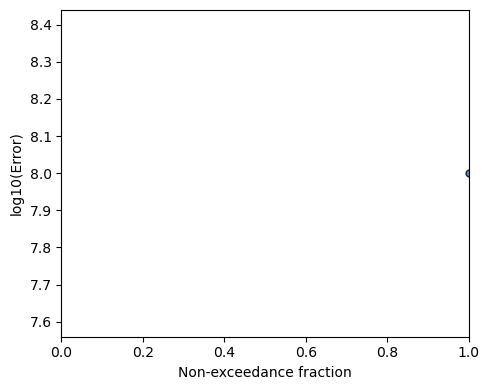

In [7]:
fit = result["fitness"]
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(fit[:, 0], fit[:, 1], s=25, edgecolor="k", alpha=0.8)
ax.set_xlabel("Non-exceedance fraction")
ax.set_xlim(0, 1)
ax.set_ylabel("log10(Error)")
plt.tight_layout()

## 7 · Save the calibrated model

We free the temporary HYPE run folders, then pickle the whole optimiser so it can be reloaded for prediction. (This file is git-ignored; the repo ships a full pre-trained model used in the next notebooks.)

In [8]:
opt.modelObject.remove_tmpFiles()
opt.save("notebook_results/my_calibration.pkl")
print("saved \u2192 notebook_results/my_calibration.pkl")

saved → notebook_results/my_calibration.pkl


## 8 · Predicting with the calibrated model

We free the temporary HYPE run folders, then pickle the whole optimiser so it can be reloaded for prediction. (This file is git-ignored; the repo ships a full pre-trained model used in the next notebooks.)

In [9]:
model = GPU_PSO.load("notebook_results/my_calibration.pkl")

obs = pd.read_csv("demo_model\Qobs.txt", sep="\t", header=0, index_col="DATE", parse_dates=True)

index1 = pd.date_range("2001-07-01", "2001-12-31", freq="D")
init_date = pd.to_datetime("2001-07-01")
final_date = pd.to_datetime("2001-12-31")
model.modelObject.init_tmpFiles()
model.modelObject.set_simulation_Dates(init_date, final_date, b_init=pd.to_datetime("2001-01-01"))
bands = model.opt['bands']
predictions_ = model.predict() #goes to the decorator which only uses self
predictions_ = processBands(predictions_, bands)
predictions_df = pd.DataFrame(predictions_, index=index1, columns=bands)
display(predictions_df.head())
predictions_df.loc[:, 'Training'] = predictions_df.index < pd.to_datetime("2001-07-01")
predictions_df.loc[:, 'Validation'] = predictions_df.index >= pd.to_datetime("2001-07-01")
predictions_df.to_csv("notebook_results/predictions.csv")

Simulations will be running in C:\Users\ruism\AppData\Local\Temp\GPU_HYPEfb8wgyry


,0.010,0.025,0.050,0.150,0.250,0.350,0.450,0.550,0.650,0.750,0.850,0.950,0.975,0.990
2001-07-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-07-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-07-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-07-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2001-07-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Plotting the predictions results in a figure with the median prediction, the observed streamflow, and optionally precipitation and temperature. The predictions are split into training and validation periods for visual inspection.

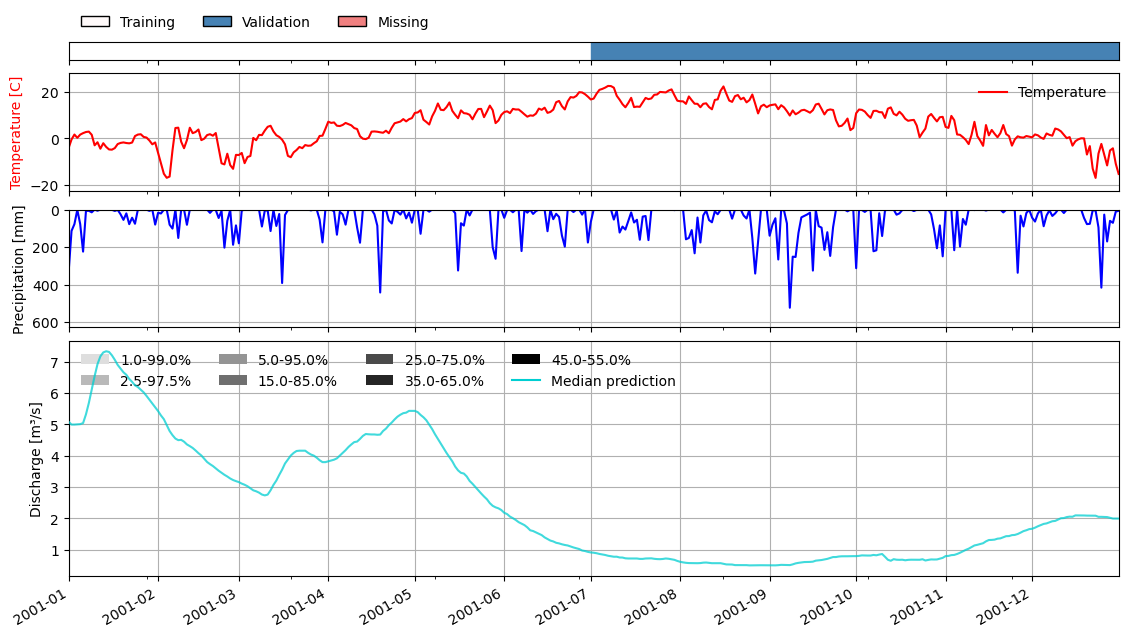

In [10]:
prec = pd.read_csv("demo_model\HYPE_setup_folder\Pobs.txt", sep="\t", header=0, index_col="DATE", parse_dates=True) 
temp = pd.read_csv("demo_model\HYPE_setup_folder\Tobs.txt", sep="\t", header=0, index_col="DATE", parse_dates=True) 
fig = plot_prediction(predictions_df, obs, temperature=temp, precipitation=prec)
